In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

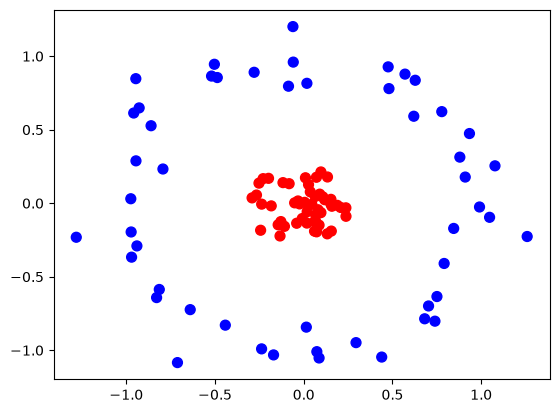

In [13]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [15]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.55

In [17]:
from matplotlib.colors import ListedColormap

# 1. Colourmap define karein (Alag line par)
zero_one_colourmap = ListedColormap(('blue', 'red'))

# 2. Function define karein
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    
    # Meshgrid banayein
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )
  
    # Contour plot
    plt.contourf(
        X1, X2, 
        clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.75, 
        cmap=zero_one_colourmap
    )
    
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    
    # Data points plot karein
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0], 
            X_set[y_set == j, 1],
            c=[zero_one_colourmap(i)], # Updated for compatibility
            label=j
        )
        
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.show()

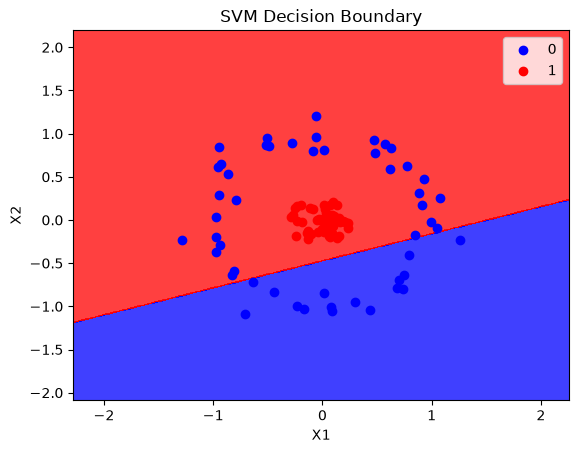

In [18]:
plot_decision_boundary(X, y, classifier)

In [19]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

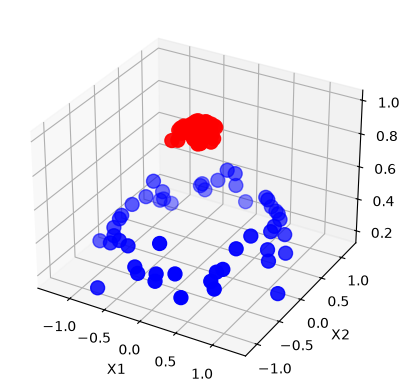

In [21]:
plot_3d_plot(X,y)
plt.show()

In [22]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [23]:
accuracy_score(y_test, y_pred)

1.0

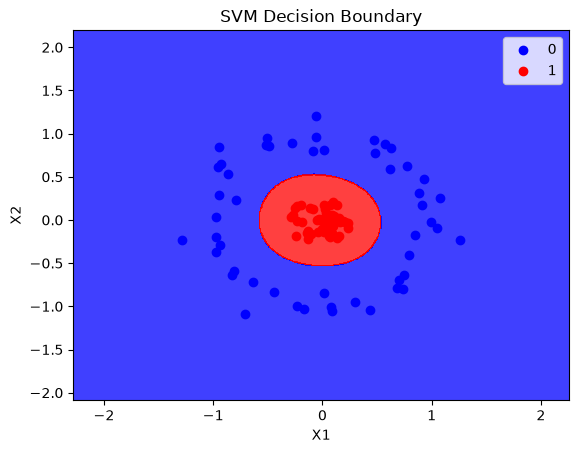

In [24]:
plot_decision_boundary(X, y, rbf_classifier)

In [25]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [26]:
accuracy_score(y_test, y_pred)

1.0